# 유형 D 상권 분석 — 용산 전세대 균형 × 환승형 매출 하락 페르소나

**분석 목적**: D유형 상권이 지금 어떤 상태이고, 왜 매출이 하락 중이며, 연령 다양성을 어떻게 소비로 전환할 수 있는가를 데이터로 제시한다.

> ⚠️ **데이터 한계**: 추론 기반 추정매출 + 길단위인구 데이터 사용. 연령 다양성은 높지만 현금·비정형 소비 포착이 어려운 계층 누락 우려 있음.

**분석 흐름**
1. 현황 — 규모·시간대·연령 분포·매출 하락 추이 + **트래픽-매출 전환율**
2. 상권 세분화 — K-Means 4개 유형 도출 (연령 다양성 × 전환율 기반)
3. 유형별 문제 진단 + 맞춤 전략 + **예상 매출 지표**
4. 지도 시각화 (유형별 색상)

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import folium
from folium.plugins import MiniMap
from pyproj import Transformer
from pathlib import Path
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

OKR_COLORS = ['#2166ac', '#d6604d', '#1a9850', '#f4a582']

BASE = (Path().resolve().parent / 'data' / 'extracted')
if not (BASE / '서울시_상권분석서비스(추정매출+영역)').exists():
    BASE = (Path().resolve() / '../data/extracted').resolve()
print(f'BASE: {BASE}')

BASE: C:\sparta\project\03_final\seouldf\data\extracted


In [15]:
# ── 1. 영역 데이터: 용산구 상권 목록 + 좌표 변환
df_area = pd.read_csv(
    BASE / '서울시_상권분석서비스(추정매출+영역)' / '서울시 상권분석서비스(영역-상권).csv',
    encoding='euc-kr'
)
TARGET_GU = ['용산구']
df_area_d = df_area[df_area['자치구_코드_명'].isin(TARGET_GU)].copy()
target_codes = set(df_area_d['상권_코드'])

# TM(EPSG:5174) → WGS84(EPSG:4326)
transformer = Transformer.from_crs('EPSG:5174', 'EPSG:4326', always_xy=True)
lons, lats = transformer.transform(
    df_area_d['엑스좌표_값'].values,
    df_area_d['와이좌표_값'].values
)
df_area_d = df_area_d.copy()
df_area_d['lat'] = lats
df_area_d['lon'] = lons

print(f'대상 상권 수: {len(df_area_d)}개')
df_area_d[['상권_코드_명', '자치구_코드_명', 'lat', 'lon']].head(5)

대상 상권 수: 57개


,상권_코드_명,자치구_코드_명,lat,lon
39,성심여자고등학교,용산구,37.535464,126.954954
40,새남터성지,용산구,37.528500,126.956486
56,후암동주민센터,용산구,37.552852,126.979988
57,해방촌예술마을,용산구,37.550077,126.984017
58,해방촌 남동측,용산구,37.546870,126.985330


In [16]:
# ── 2. 추정매출 2025년 (전 분기) + 용산구 필터 — 추이 분석용
df_sales_raw = pd.read_csv(
    BASE / '서울시_상권분석서비스(추정매출+영역)' / '서울시_상권분석서비스(추정매출-상권)_2025년.csv',
    encoding='euc-kr'
)
df_sales_all_d = df_sales_raw[df_sales_raw['상권_코드'].isin(target_codes)].copy()

# 2025Q4 단면 (클러스터링·주분석용)
df_sales_d = df_sales_all_d[df_sales_all_d['기준_년분기_코드'] == 20254].copy()

# ── 3. 2024년 매출 데이터 (추이 비교용)
_sales_dir = BASE / '서울시_상권분석서비스(추정매출+영역)'
_sales_2024_files = [f for f in _sales_dir.iterdir() if '2024' in f.name and f.suffix == '.csv']
if _sales_2024_files:
    df_sales_2024_raw = pd.read_csv(_sales_2024_files[0], encoding='euc-kr')
    df_sales_2024_d = df_sales_2024_raw[df_sales_2024_raw['상권_코드'].isin(target_codes)].copy()
    df_trend = pd.concat([df_sales_2024_d, df_sales_all_d], ignore_index=True)
else:
    df_trend = df_sales_all_d.copy()

# ── 4. 길단위 인구 + 용산구 필터
df_pop_raw = pd.read_csv(
    BASE / '서울시 상권분석서비스(길단위인구-상권)' / '서울시 상권분석서비스(길단위인구-상권).csv',
    encoding='euc-kr'
)
df_pop_d = df_pop_raw[df_pop_raw['상권_코드'].isin(target_codes)].copy()

print(f'추정매출(2025Q4): {len(df_sales_d)}행 / {df_sales_d["상권_코드"].nunique()}개 상권')
print(f'추이 데이터: {df_trend["기준_년분기_코드"].nunique()}개 분기 / {df_trend["기준_년분기_코드"].unique()}')
print(f'길단위인구: {len(df_pop_d)}행 / 분기: {df_pop_d["기준_년분기_코드"].unique()[:5]}')
print(f'업종 종류: {df_sales_d["서비스_업종_코드_명"].nunique()}개')
df_sales_d[['상권_코드_명', '서비스_업종_코드_명', '당월_매출_금액', '당월_매출_건수']].head(5)

추정매출(2025Q4): 667행 / 53개 상권
추이 데이터: 8개 분기 / [20241 20242 20243 20244 20254 20253 20252 20251]
길단위인구: 1596행 / 분기: [20254 20253 20252 20251 20244]
업종 종류: 58개


,상권_코드_명,서비스_업종_코드_명,당월_매출_금액,당월_매출_건수
215,이태원 관광특구,전자상거래업,51037665,1287
216,이태원 관광특구,가구,48062972,29
217,이태원 관광특구,화초,73695474,1637
218,이태원 관광특구,섬유제품,69694770,74
219,이태원 관광특구,운동/경기용품,665300432,4509


In [17]:
# ── 상권별 핵심 지표 집계 (클러스터링 피처 포함)
g = df_sales_d.groupby('상권_코드').agg(
    총매출=('당월_매출_금액', 'sum'),
    총건수=('당월_매출_건수', 'sum'),
    오전매출=('시간대_06~11_매출_금액', 'sum'),
    점심매출=('시간대_11~14_매출_금액', 'sum'),
    오후매출=('시간대_14~17_매출_금액', 'sum'),
    저녁매출=('시간대_17~21_매출_금액', 'sum'),
    야간매출=('시간대_21~24_매출_금액', 'sum'),
    주중매출=('주중_매출_금액', 'sum'),
    주말매출=('주말_매출_금액', 'sum'),
    주중건수=('주중_매출_건수', 'sum'),
    주말건수=('주말_매출_건수', 'sum'),
    남성매출=('남성_매출_금액', 'sum'),
    여성매출=('여성_매출_금액', 'sum'),
    연령20매출=('연령대_20_매출_금액', 'sum'),
    연령30매출=('연령대_30_매출_금액', 'sum'),
    연령40매출=('연령대_40_매출_금액', 'sum'),
    연령50매출=('연령대_50_매출_금액', 'sum'),
    연령60매출=('연령대_60_이상_매출_금액', 'sum'),
).reset_index()

# 비율 피처 (클러스터링에 사용)
g['점심비중'] = g['점심매출'] / g['총매출']
g['저녁비중'] = g['저녁매출'] / g['총매출']
g['야간비중'] = g['야간매출'] / g['총매출']
g['주말비중'] = g['주말매출'] / g['총매출']
g['여성비중'] = g['여성매출'] / g['총매출']
g['객단가'] = g['총매출'] / g['총건수'].replace(0, np.nan)

# ── 연령 다양성 지수 (Shannon Entropy — 클수록 연령 분포가 고름)
age_cols_매출 = ['연령20매출', '연령30매출', '연령40매출', '연령50매출', '연령60매출']
age_mat = g[age_cols_매출].values.astype(float)
age_mat_sum = age_mat.sum(axis=1, keepdims=True)
age_prob = np.where(age_mat_sum > 0, age_mat / age_mat_sum, 0)
# Shannon entropy (0~log(5) 범위, 정규화 → 0~1)
with np.errstate(divide='ignore', invalid='ignore'):
    entropy = -np.nansum(np.where(age_prob > 0, age_prob * np.log(age_prob), 0), axis=1)
g['연령다양성'] = entropy / np.log(5)  # 0~1 정규화

# ── 연령 편중 (가장 높은 연령대 비중 — 1이면 완전 편중)
age_names = ['연령20', '연령30', '연령40', '연령50', '연령60']
for col, name in zip(age_cols_매출, age_names):
    g[f'{name}비중'] = g[col] / g['총매출']
g['주력연령편중'] = age_prob.max(axis=1)
g['주력연령대'] = pd.Categorical(
    [age_names[i] for i in age_prob.argmax(axis=1)],
    categories=age_names
)

# ── 길단위 트래픽 (2025Q4 기준 상권별 총 통행인구)
pop_latest = df_pop_d[df_pop_d['기준_년분기_코드'] == 20254].copy()
pop_agg = pop_latest.groupby('상권_코드').agg(
    총통행인구=('총_유동인구_수', 'sum') if '총_유동인구_수' in pop_latest.columns
    else ('총_생활인구_수', 'sum') if '총_생활인구_수' in pop_latest.columns
    else (pop_latest.select_dtypes('number').columns[2], 'sum')
).reset_index()
pop_agg.columns = ['상권_코드', '총통행인구']

# 상권명·좌표 합류
g = g.merge(
    df_area_d[['상권_코드', '상권_코드_명', '자치구_코드_명', 'lat', 'lon']],
    on='상권_코드', how='left'
)
g = g.merge(pop_agg, on='상권_코드', how='left')

# 트래픽-매출 전환율 (통행인구 1인당 매출액, 낮을수록 환승형)
g['트래픽전환율'] = (g['총매출'] / g['총통행인구'].replace(0, np.nan)).fillna(0)
g['트래픽전환율_norm'] = (g['트래픽전환율'] - g['트래픽전환율'].min()) / \
    (g['트래픽전환율'].max() - g['트래픽전환율'].min() + 1e-9)

g = g.dropna(subset=['총매출', '점심비중', '저녁비중', '야간비중', '주말비중', '여성비중', '객단가'])
g = g[g['총매출'] > 0].reset_index(drop=True)
g['총매출_억'] = g['총매출'] / 1e8

print(f'분석 상권: {len(g)}개')
print(f'월 평균 매출: {g["총매출_억"].mean():.1f}억원  (중앙값 {g["총매출_억"].median():.1f}억원)')
print(f'객단가 중앙값: {g["객단가"].median():,.0f}원')
print(f'연령 다양성 지수 평균: {g["연령다양성"].mean():.3f}  (1.0 = 완전 균등 분포)')
print(f'트래픽 전환율 중앙값: {g["트래픽전환율"].median():,.0f}원/인')

분석 상권: 53개
월 평균 매출: 237.5억원  (중앙값 43.8억원)
객단가 중앙값: 34,581원
연령 다양성 지수 평균: 0.929  (1.0 = 완전 균등 분포)
트래픽 전환율 중앙값: 8,125원/인


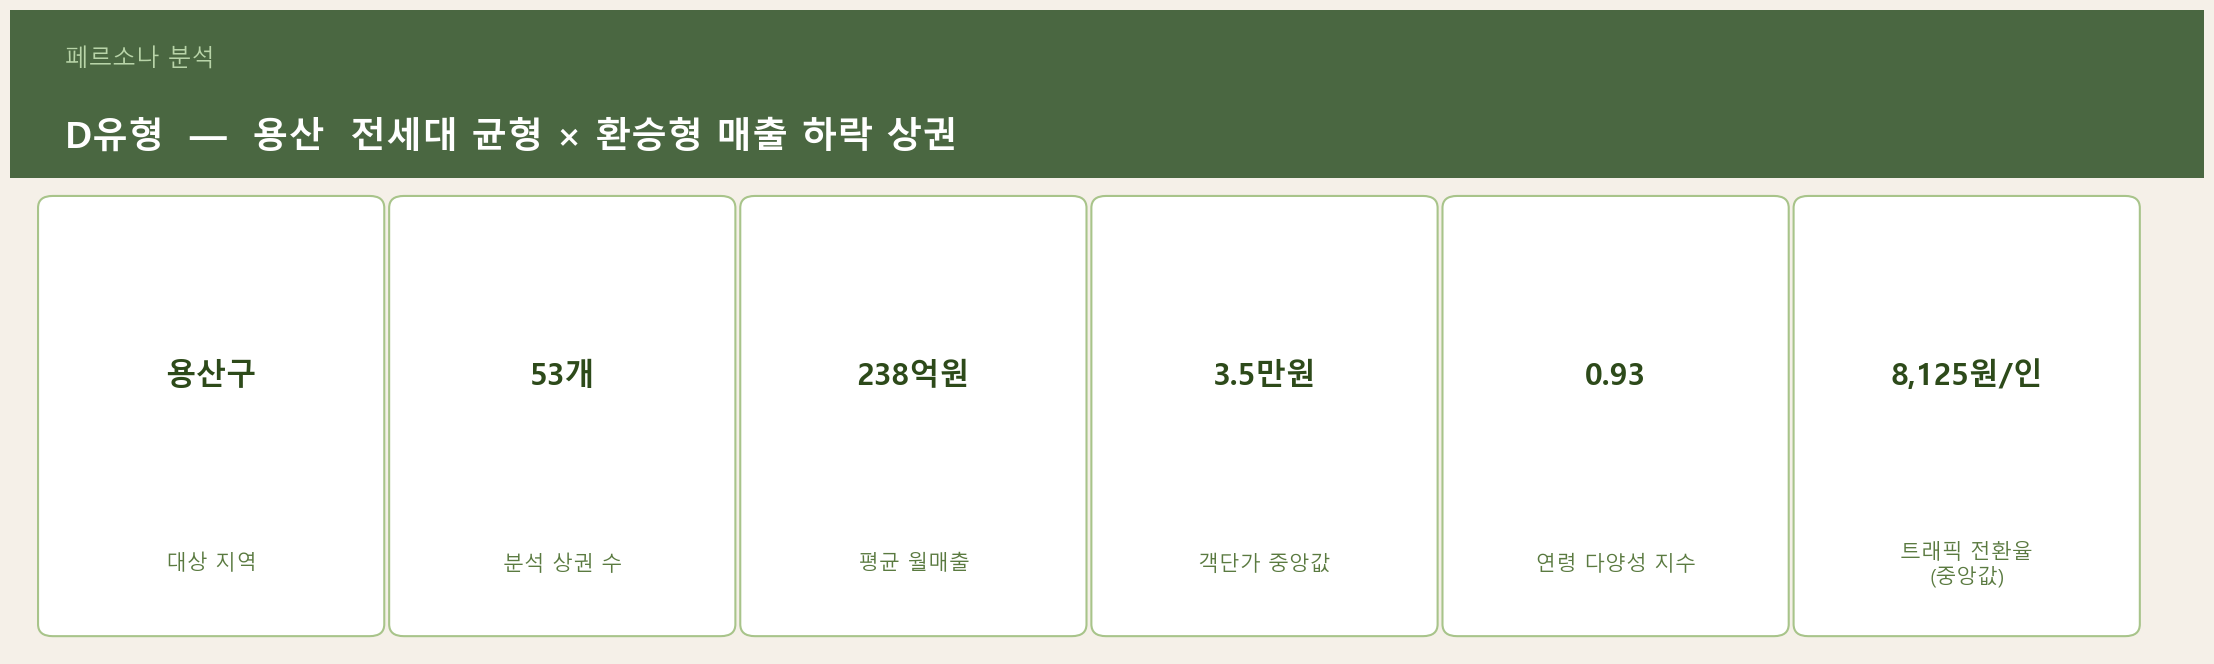

In [18]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

avg_sales    = g['총매출_억'].mean()
median_unit  = g['객단가'].median()
diversity    = g['연령다양성'].mean()
convert_rate = g['트래픽전환율'].median()

attrs = [
    ('대상 지역',       '용산구'),
    ('분석 상권 수',     f'{len(g)}개'),
    ('평균 월매출',      f'{avg_sales:.0f}억원'),
    ('객단가 중앙값',     f'{median_unit/10000:.1f}만원'),
    ('연령 다양성 지수',  f'{diversity:.2f}'),
    ('트래픽 전환율\n(중앙값)', f'{convert_rate:,.0f}원/인'),
]

fig = plt.figure(figsize=(22, 6.5))
ax  = fig.add_subplot(111)
ax.set_xlim(0, 18)
ax.set_ylim(0, 6.5)
ax.axis('off')
fig.patch.set_facecolor('#f5f0e8')
ax.set_facecolor('#f5f0e8')

# 헤더 (전세대 균형 — 웜 그린·골드 계열)
ax.add_patch(FancyBboxPatch((0, 4.8), 18, 1.7, boxstyle='square,pad=0',
                             facecolor='#4a6741', edgecolor='none'))
ax.text(0.45, 6.0, '페르소나 분석', fontsize=17, color='#b8d4a8', va='center', style='italic')
ax.text(0.45, 5.2, 'D유형  —  용산  전세대 균형 × 환승형 매출 하락 상권',
        fontsize=26, color='white', fontweight='bold', va='center')

box_w, gap, start_x = 2.6, 0.28, 0.35
for i, (label, value) in enumerate(attrs):
    x = start_x + i * (box_w + gap)
    ax.add_patch(FancyBboxPatch((x, 0.3), box_w, 4.2,
                                 boxstyle='round,pad=0.12',
                                 facecolor='white', edgecolor='#a8c48a', linewidth=1.5))
    ax.text(x + box_w / 2, 2.8, value,
            ha='center', va='center', fontsize=22, color='#2d4a1a',
            fontweight='bold', multialignment='center', linespacing=1.3)
    ax.text(x + box_w / 2, 0.9, label,
            ha='center', va='center', fontsize=15, color='#5a7a40')

plt.tight_layout(pad=0.2)
plt.savefig('../data/output/D유형_페르소나카드.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 1. D유형 현황 — 용산 상권은 지금 어디에 있는가

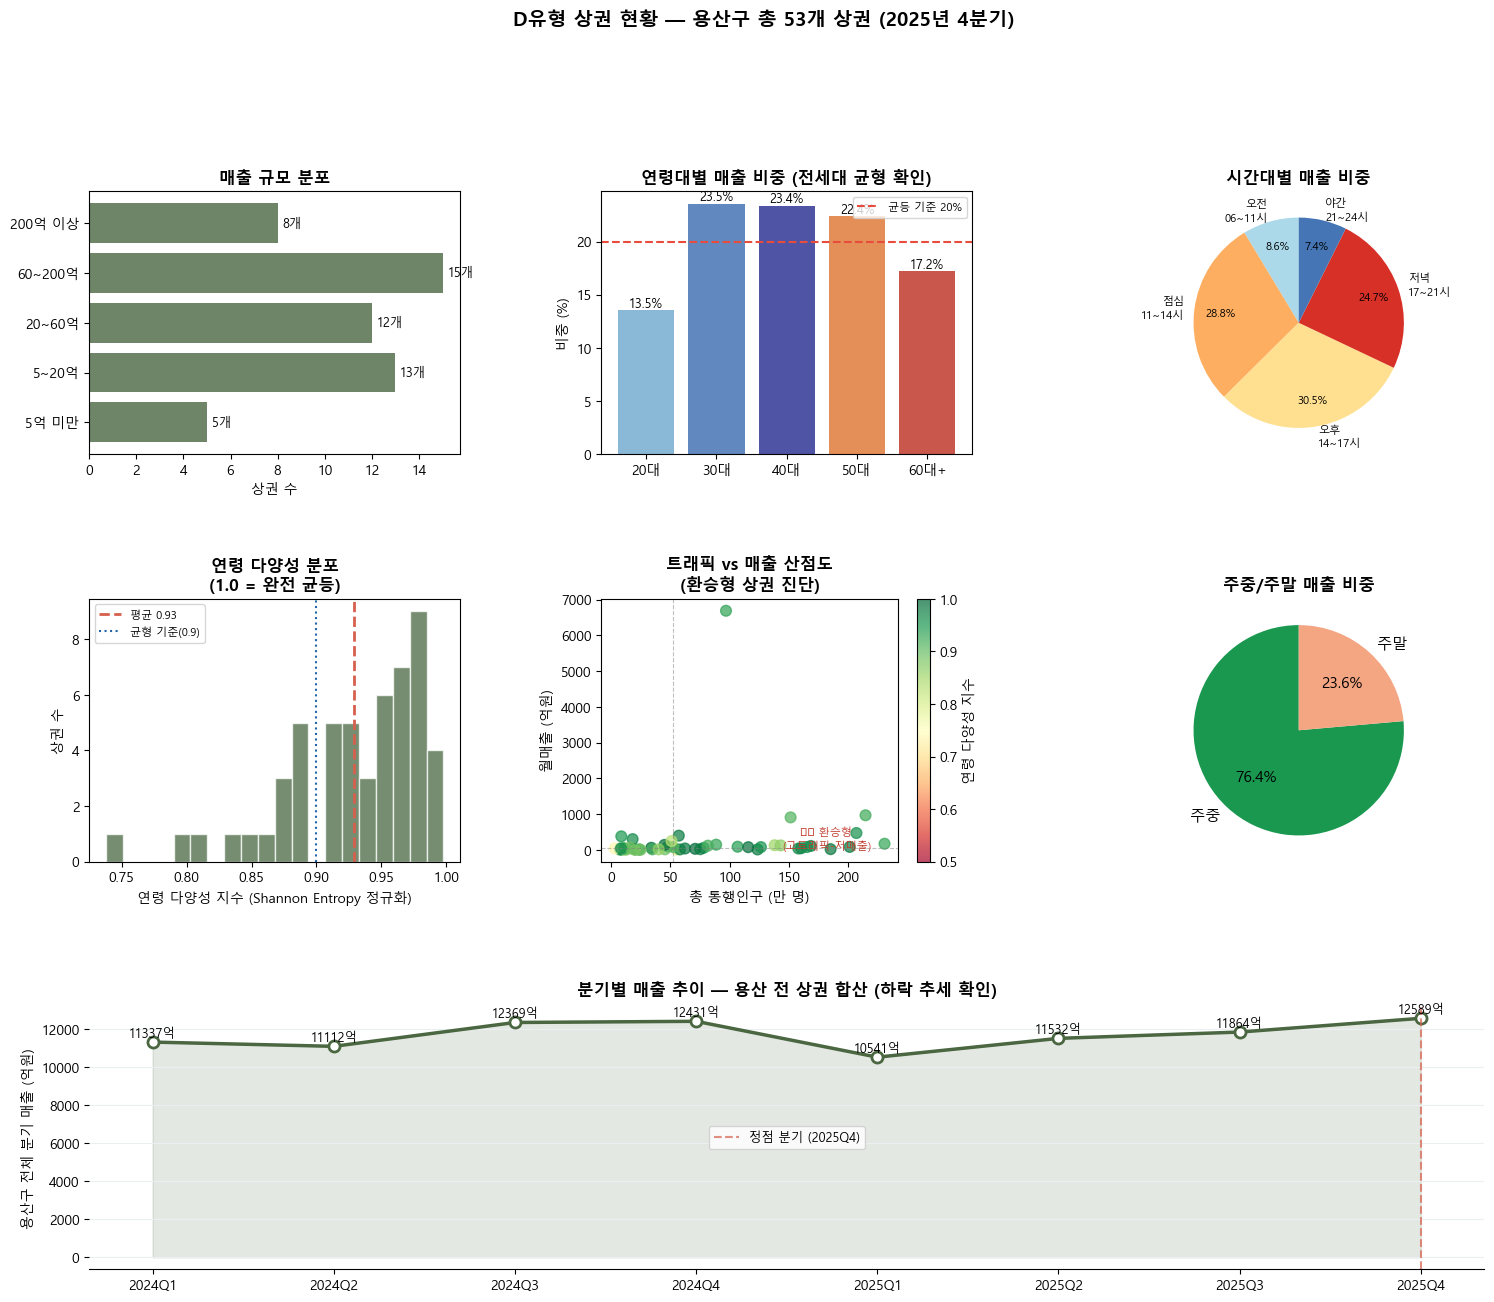

In [19]:
fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.38)

# ── (1) 매출 규모 분포
ax1 = fig.add_subplot(gs[0, 0])
bins = [0, 5, 20, 60, 200, g['총매출_억'].max() + 1]
labels_bin = ['5억 미만', '5~20억', '20~60억', '60~200억', '200억 이상']
g['매출구간'] = pd.cut(g['총매출_억'], bins=bins, labels=labels_bin)
매출구간_cnt = g['매출구간'].value_counts().reindex(labels_bin)
bars = ax1.barh(labels_bin, 매출구간_cnt.values, color='#4a6741', alpha=0.8)
for bar, val in zip(bars, 매출구간_cnt.values):
    ax1.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
             f'{val}개', va='center', fontsize=9)
ax1.set_xlabel('상권 수')
ax1.set_title('매출 규모 분포', fontweight='bold')

# ── (2) 연령대별 매출 비중 (전세대 균형 강조)
ax2 = fig.add_subplot(gs[0, 1])
age_cols_plot = ['연령20매출', '연령30매출', '연령40매출', '연령50매출', '연령60매출']
age_labels = ['20대', '30대', '40대', '50대', '60대+']
age_vals = [g[c].sum() for c in age_cols_plot]
colors_a = ['#74add1', '#4575b4', '#313695', '#e07b39', '#c0392b']
bars2 = ax2.bar(age_labels, [v/sum(age_vals)*100 for v in age_vals],
                color=colors_a, alpha=0.85)
for i, v in enumerate([v/sum(age_vals)*100 for v in age_vals]):
    ax2.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)
# 균등 기준선 (20%)
ax2.axhline(20, color='#e74c3c', linestyle='--', linewidth=1.5, label='균등 기준 20%')
ax2.set_ylabel('비중 (%)')
ax2.set_title('연령대별 매출 비중 (전세대 균형 확인)', fontweight='bold')
ax2.legend(fontsize=8)

# ── (3) 시간대별 매출 비중
ax3 = fig.add_subplot(gs[0, 2])
time_cols   = ['오전매출', '점심매출', '오후매출', '저녁매출', '야간매출']
time_labels_t = ['오전\n06~11시', '점심\n11~14시', '오후\n14~17시', '저녁\n17~21시', '야간\n21~24시']
time_vals   = [g[c].sum() for c in time_cols]
time_pct    = [v / sum(time_vals) * 100 for v in time_vals]
colors_t    = ['#abd9e9', '#fdae61', '#fee090', '#d73027', '#4575b4']
wedges, texts, autotexts = ax3.pie(
    time_pct, labels=time_labels_t, autopct='%1.1f%%',
    colors=colors_t, startangle=90, pctdistance=0.75,
    textprops={'fontsize': 8}
)
for at in autotexts:
    at.set_fontsize(8)
ax3.set_title('시간대별 매출 비중', fontweight='bold')

# ── (4) 연령 다양성 지수 분포 (히스토그램)
ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(g['연령다양성'], bins=20, color='#4a6741', alpha=0.75, edgecolor='white')
ax4.axvline(g['연령다양성'].mean(), color='#d6604d', lw=2, linestyle='--',
            label=f'평균 {g["연령다양성"].mean():.2f}')
ax4.axvline(0.9, color='#2166ac', lw=1.5, linestyle=':',
            label='균형 기준(0.9)')
ax4.set_xlabel('연령 다양성 지수 (Shannon Entropy 정규화)')
ax4.set_ylabel('상권 수')
ax4.set_title('연령 다양성 분포\n(1.0 = 완전 균등)', fontweight='bold')
ax4.legend(fontsize=8)

# ── (5) 트래픽-매출 산점도 (환승형 진단)
ax5 = fig.add_subplot(gs[1, 1])
scatter_data = g.dropna(subset=['총통행인구', '총매출_억'])
if len(scatter_data) > 0 and scatter_data['총통행인구'].max() > 0:
    sc = ax5.scatter(
        scatter_data['총통행인구'] / 1e4,
        scatter_data['총매출_억'],
        c=scatter_data['연령다양성'],
        cmap='RdYlGn', alpha=0.7, s=60, vmin=0.5, vmax=1.0
    )
    plt.colorbar(sc, ax=ax5, label='연령 다양성 지수')
    # 환승형 구역 표시 (고트래픽-저매출)
    tr_med = scatter_data['총통행인구'].median() / 1e4
    sa_med = scatter_data['총매출_억'].median()
    ax5.axvline(tr_med, color='gray', lw=0.8, linestyle='--', alpha=0.5)
    ax5.axhline(sa_med, color='gray', lw=0.8, linestyle='--', alpha=0.5)
    ax5.text(ax5.get_xlim()[1]*0.75, sa_med*0.3, '⚠️ 환승형\n(고트래픽-저매출)',
             fontsize=8, color='#c0392b', ha='center')
    ax5.set_xlabel('총 통행인구 (만 명)')
    ax5.set_ylabel('월매출 (억원)')
    ax5.set_title('트래픽 vs 매출 산점도\n(환승형 상권 진단)', fontweight='bold')
else:
    ax5.text(0.5, 0.5, '트래픽 데이터 없음', ha='center', va='center', transform=ax5.transAxes)
    ax5.set_title('트래픽 vs 매출 산점도', fontweight='bold')

# ── (6) 주중/주말 매출 비중
ax6 = fig.add_subplot(gs[1, 2])
wd = g['주중매출'].sum()
we = g['주말매출'].sum()
ax6.pie([wd, we], labels=['주중', '주말'],
        autopct='%1.1f%%', colors=['#1a9850', '#f4a582'],
        startangle=90, textprops={'fontsize': 11})
ax6.set_title('주중/주말 매출 비중', fontweight='bold')

# ── (7) 분기별 총매출 추이 (하락 추이 확인)
ax7 = fig.add_subplot(gs[2, :])
trend_q = df_trend.groupby('기준_년분기_코드').agg(
    분기_총매출=('당월_매출_금액', 'sum')
).reset_index().sort_values('기준_년분기_코드')
trend_q['분기_총매출_억'] = trend_q['분기_총매출'] / 1e8
qcodes = trend_q['기준_년분기_코드'].astype(str)
q_labels = [f"{c[:4]}Q{c[4]}" for c in qcodes]
ax7.plot(q_labels, trend_q['분기_총매출_억'].values, 'o-',
         color='#4a6741', linewidth=2.5, markersize=8, markerfacecolor='white', markeredgewidth=2)
ax7.fill_between(q_labels, trend_q['분기_총매출_억'].values, alpha=0.15, color='#4a6741')

# 하락 강조
peak_idx = trend_q['분기_총매출_억'].idxmax()
peak_q   = q_labels[list(trend_q.index).index(peak_idx)] if peak_idx in trend_q.index else q_labels[0]
ax7.axvline(peak_q, color='#d6604d', lw=1.5, linestyle='--', alpha=0.7, label=f'정점 분기 ({peak_q})')

for i, (ql, val) in enumerate(zip(q_labels, trend_q['분기_총매출_억'].values)):
    ax7.text(i, val + trend_q['분기_총매출_억'].max() * 0.02,
             f'{val:.0f}억', ha='center', fontsize=9)

ax7.set_ylabel('용산구 전체 분기 매출 (억원)', fontsize=10)
ax7.set_title('분기별 매출 추이 — 용산 전 상권 합산 (하락 추세 확인)', fontweight='bold', pad=8)
ax7.grid(axis='y', linestyle='-', color='#ECEFF1', zorder=0)
ax7.legend(fontsize=9)
sns.despine(ax=ax7, left=True)

fig.suptitle(f'D유형 상권 현황 — 용산구 총 {len(g)}개 상권 (2025년 4분기)',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig('../data/output/D유형_현황.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2. 상권 세분화 — 데이터가 말하는 4가지 유형

연령 다양성 × 트래픽 전환율 × 시간대·요일 패턴으로 K-Means 클러스터링을 수행한다.  
D유형의 핵심 질문: **연령 다양성이 높은 상권이 왜 매출 전환에 실패하는가?**

In [20]:
FEAT_COLS = ['점심비중', '저녁비중', '야간비중', '주말비중', '여성비중', '연령다양성']
g['log_객단가'] = np.log(g['객단가'])
g['트래픽전환율_log'] = np.log1p(g['트래픽전환율'].fillna(0))
FEAT_ALL = FEAT_COLS + ['log_객단가', '트래픽전환율_log']

X_raw = g[FEAT_ALL].fillna(0).values
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

sil_scores = {}
for k in range(2, 7):
    km_tmp = KMeans(n_clusters=k, random_state=42, n_init=10)
    sil_scores[k] = silhouette_score(X, km_tmp.fit_predict(X))
best_k = max(sil_scores, key=sil_scores.get)
print(f'Silhouette scores: {sil_scores}')
print(f'최적 k = {best_k}')

K = 4
km = KMeans(n_clusters=K, random_state=42, n_init=10)
g['클러스터'] = km.fit_predict(X)

profile = g.groupby('클러스터')[FEAT_COLS + ['총매출_억', '객단가', '트래픽전환율']].mean()
print('\n클러스터별 평균 프로파일:')
print(profile.round(3))

names_pool = ['① 전세대 고트래픽-저전환형 (환승형)', '② 연령 편중 안정형', '③ 전세대 균형 소비 전환형', '④ 전체 하락 취약형']

assigned = {}
# 트래픽전환율 최저 + 연령다양성 최고 → 환승형
max_diversity = profile['연령다양성'].idxmax()
min_convert   = profile['트래픽전환율'].idxmin()
# 두 조건이 겹치면 환승형에 할당
환승형_idx = max_diversity if profile.loc[max_diversity, '트래픽전환율'] <= profile['트래픽전환율'].median() else min_convert
assigned[환승형_idx] = '① 전세대 고트래픽-저전환형 (환승형)'

# 트래픽전환율 최고 + 연령다양성 높음 → 소비전환형
for idx in profile['트래픽전환율'].sort_values(ascending=False).index:
    if idx not in assigned:
        assigned[idx] = '③ 전세대 균형 소비 전환형'
        break

# 연령다양성 최저 → 연령 편중 안정형
for idx in profile['연령다양성'].sort_values(ascending=True).index:
    if idx not in assigned:
        assigned[idx] = '② 연령 편중 안정형'
        break

# 나머지 → 전체 하락 취약형
for idx in profile.index:
    if idx not in assigned:
        assigned[idx] = '④ 전체 하락 취약형'

profile['유형명'] = pd.Series(assigned)
g['유형명'] = g['클러스터'].map(assigned)

유형_순서 = names_pool

print('\n유형별 상권 수:')
print(g['유형명'].value_counts())

Silhouette scores: {2: 0.18986619608783606, 3: 0.217790297029346, 4: 0.234659656544877, 5: 0.19542630723325452, 6: 0.18030552008079226}
최적 k = 4

클러스터별 평균 프로파일:
       점심비중   저녁비중   야간비중   주말비중   여성비중  연령다양성     총매출_억         객단가  \
클러스터                                                                   
0     0.280  0.303  0.095  0.240  0.376  0.955    63.257   32320.834   
1     0.172  0.386  0.195  0.336  0.398  0.934   176.574   60431.190   
2     0.333  0.115  0.004  0.117  0.154  0.911  2399.046  206769.194   
3     0.266  0.277  0.041  0.241  0.565  0.833    74.074   31716.694   

          트래픽전환율  
클러스터              
0       7951.276  
1      30160.290  
2     384046.080  
3      39405.980  

유형별 상권 수:
유형명
① 전세대 고트래픽-저전환형 (환승형)    24
④ 전체 하락 취약형              19
② 연령 편중 안정형               7
③ 전세대 균형 소비 전환형           3
Name: count, dtype: int64


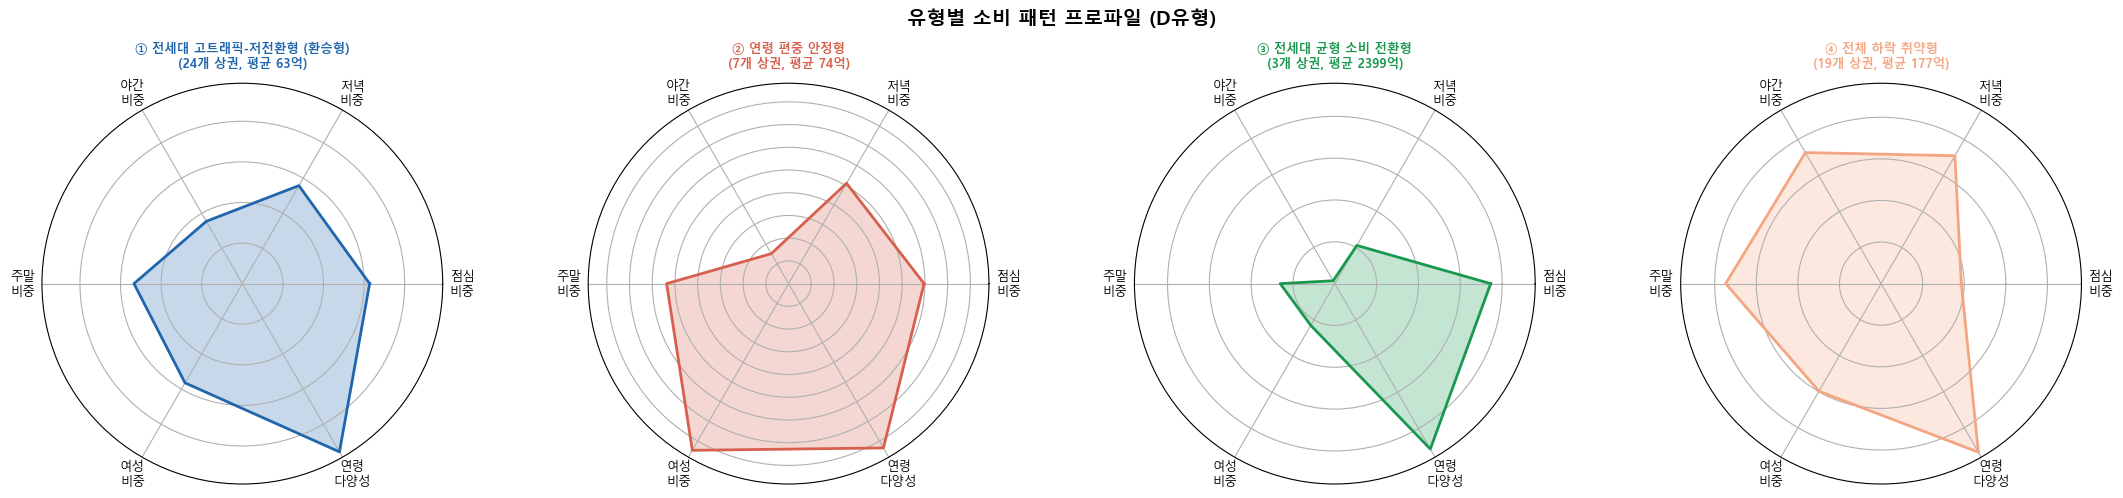

In [21]:
# ── 클러스터 프로파일 레이더 차트
color_map = {유형: OKR_COLORS[i] for i, 유형 in enumerate(유형_순서)}

radar_feats  = ['점심비중', '저녁비중', '야간비중', '주말비중', '여성비중', '연령다양성']
radar_labels = ['점심\n비중', '저녁\n비중', '야간\n비중', '주말\n비중', '여성\n비중', '연령\n다양성']
N = len(radar_feats)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

유형_to_cluster = {v: k for k, v in assigned.items()}

fig, axes = plt.subplots(1, 4, figsize=(22, 5), subplot_kw=dict(polar=True))
fig.suptitle('유형별 소비 패턴 프로파일 (D유형)', fontsize=14, fontweight='bold')

for ax, 유형 in zip(axes, 유형_순서):
    cid = 유형_to_cluster.get(유형)
    if cid is None:
        continue
    subset = g[g['클러스터'] == cid]
    vals = [subset[f].mean() for f in radar_feats]
    global_max = [g[f].max() for f in radar_feats]
    vals_norm = [v / m if m > 0 else 0 for v, m in zip(vals, global_max)]
    vals_norm += vals_norm[:1]

    ax.plot(angles, vals_norm, color=color_map[유형], linewidth=2)
    ax.fill(angles, vals_norm, alpha=0.25, color=color_map[유형])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels, fontsize=9)
    ax.set_yticklabels([])
    ax.set_title(
        f'{유형}\n({len(subset)}개 상권, 평균 {subset["총매출_억"].mean():.0f}억)',
        fontsize=9, fontweight='bold', color=color_map[유형], pad=12
    )

plt.tight_layout()
plt.savefig('../data/output/D유형_클러스터_레이더.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. 유형별 문제 진단 + 맞춤 전략 + 예상 매출 지표


  ① 전세대 고트래픽-저전환형 (환승형)  (24개 상권)
  [문제점] 연령 다양성은 가장 높지만 통행 인구가 매출로 전환되지 않음. 용산역·삼각지 환승 동선에서 상권을 스쳐 지나가는 '환승형/통과형' 상권으로 전락. 체류 유인 콘텐츠 부재가 핵심 원인.
    1. 역세권 체류 유인형 팝업·복합문화 거점 조성 (서울시 역세권 청년주택·상권 활성화 사업 응용: 역 출구 반경 100m 체험존 → 환승 동선을 소비 동선으로 전환)
    2. 전세대 참여형 로컬 콘텐츠 큐레이션 (용산 전자상가·전쟁기념관·이태원 연계 스탬프 랠리 → 20~50대 모두 동선 이탈 없이 체류 시간 확보)
  현재 32.6억 → 목표 34.1억 (+4.6%), 연간효과 214억

  ② 연령 편중 안정형  (7개 상권)
  [문제점] 특정 연령대(30~40대 직장인 또는 50대 거주민)에 매출 집중. 다른 연령대 유입 채널 부재로 성장 한계 봉착. 편중된 타겟 이탈 시 급격한 매출 하락 위험.
    1. 세대 간 연계 업종 믹스 큐레이션 (서울시 상권분석서비스 기반 공백 업종 발굴 → 현재 집중 연령 이외 세대 유입 견인, 가족 단위 방문 구조로 전환)
    2. 연령대별 채널 분리 마케팅 (20대: 인스타그램·TikTok, 30~40대: 카카오채널·네이버플레이스, 50대: 오프라인 전단·지역 커뮤니티 → 다연령 동시 공략)
  현재 39.2억 → 목표 41.4억 (+5.7%), 연간효과 94억

  ③ 전세대 균형 소비 전환형  (3개 상권)
  [문제점] 연령 균형과 매출 전환이 가장 우수하지만 용산 전체 하락 트렌드에서 벗어나지 못하는 상황. 지속성 담보 없이 현재 강점만으로는 매출 성장 한계.
    1. 서울시 상권 르네상스 사업 신청 (매출 하락 구간 기준 신청 가능, 2년 내 매출 +20% 사례 다수 — 현재 강점을 발판으로 상위 상권 도약 시도)
    2. 용산 정비창·철도부지 개발 연계 선제적 포지셔닝 (2030년 준공 예정 용산 국제업무지구 수요 선점 → 지

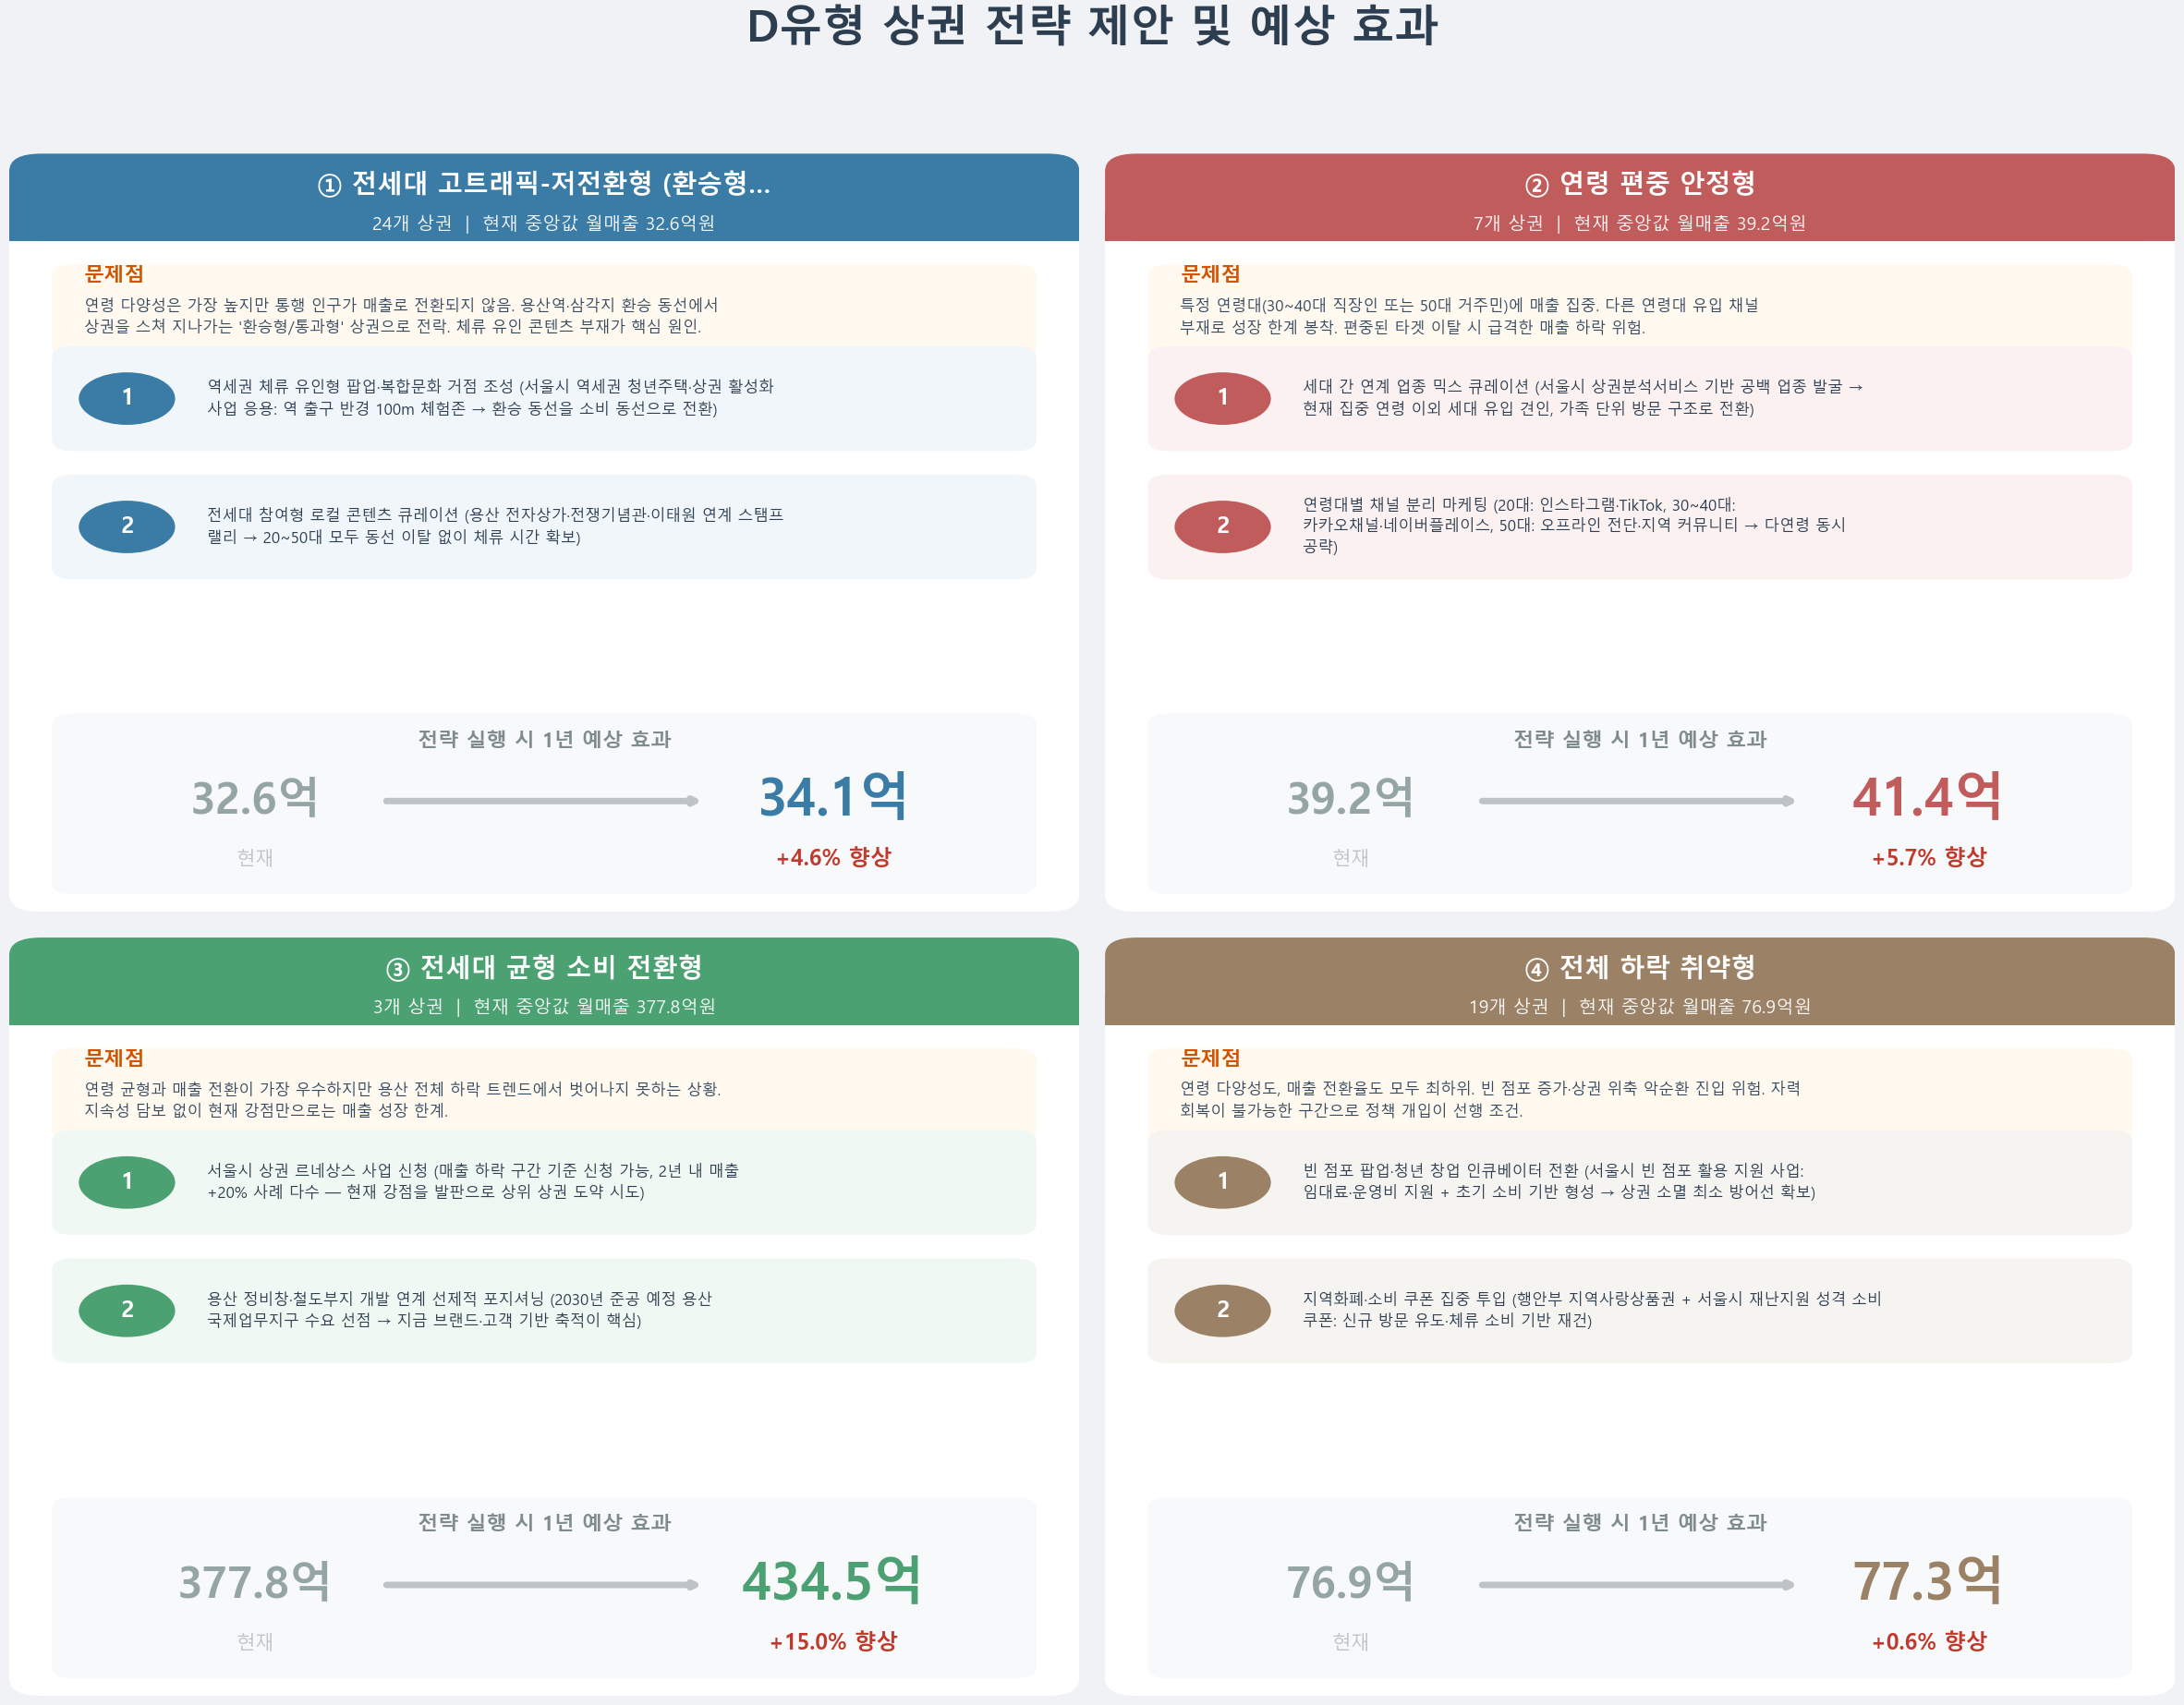

In [22]:
import textwrap, re
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

strategy_info = {
    '① 전세대 고트래픽-저전환형 (환승형)': {
        '문제': '연령 다양성은 가장 높지만 통행 인구가 매출로 전환되지 않음. 용산역·삼각지 환승 동선에서 상권을 스쳐 지나가는 \'환승형/통과형\' 상권으로 전락. 체류 유인 콘텐츠 부재가 핵심 원인.',
        '전략': [
            '1. 역세권 체류 유인형 팝업·복합문화 거점 조성 (서울시 역세권 청년주택·상권 활성화 사업 응용: 역 출구 반경 100m 체험존 → 환승 동선을 소비 동선으로 전환)',
            '2. 전세대 참여형 로컬 콘텐츠 큐레이션 (용산 전자상가·전쟁기념관·이태원 연계 스탬프 랠리 → 20~50대 모두 동선 이탈 없이 체류 시간 확보)',
        ],
    },
    '② 연령 편중 안정형': {
        '문제': '특정 연령대(30~40대 직장인 또는 50대 거주민)에 매출 집중. 다른 연령대 유입 채널 부재로 성장 한계 봉착. 편중된 타겟 이탈 시 급격한 매출 하락 위험.',
        '전략': [
            '1. 세대 간 연계 업종 믹스 큐레이션 (서울시 상권분석서비스 기반 공백 업종 발굴 → 현재 집중 연령 이외 세대 유입 견인, 가족 단위 방문 구조로 전환)',
            '2. 연령대별 채널 분리 마케팅 (20대: 인스타그램·TikTok, 30~40대: 카카오채널·네이버플레이스, 50대: 오프라인 전단·지역 커뮤니티 → 다연령 동시 공략)',
        ],
    },
    '③ 전세대 균형 소비 전환형': {
        '문제': '연령 균형과 매출 전환이 가장 우수하지만 용산 전체 하락 트렌드에서 벗어나지 못하는 상황. 지속성 담보 없이 현재 강점만으로는 매출 성장 한계.',
        '전략': [
            '1. 서울시 상권 르네상스 사업 신청 (매출 하락 구간 기준 신청 가능, 2년 내 매출 +20% 사례 다수 — 현재 강점을 발판으로 상위 상권 도약 시도)',
            '2. 용산 정비창·철도부지 개발 연계 선제적 포지셔닝 (2030년 준공 예정 용산 국제업무지구 수요 선점 → 지금 브랜드·고객 기반 축적이 핵심)',
        ],
    },
    '④ 전체 하락 취약형': {
        '문제': '연령 다양성도, 매출 전환율도 모두 최하위. 빈 점포 증가·상권 위축 악순환 진입 위험. 자력 회복이 불가능한 구간으로 정책 개입이 선행 조건.',
        '전략': [
            '1. 빈 점포 팝업·청년 창업 인큐베이터 전환 (서울시 빈 점포 활용 지원 사업: 임대료·운영비 지원 + 초기 소비 기반 형성 → 상권 소멸 최소 방어선 확보)',
            '2. 지역화폐·소비 쿠폰 집중 투입 (행안부 지역사랑상품권 + 서울시 재난지원 성격 소비 쿠폰: 신규 방문 유도·체류 소비 기반 재건)',
        ],
    },
}

results = {}
for 유형 in 유형_순서:
    cid = 유형_to_cluster.get(유형)
    if cid is None:
        continue
    subset = g[g['클러스터'] == cid]
    현재 = subset['총매출_억'].median()
    상권수 = len(subset)
    현실적_벤치마크 = subset['총매출_억'].quantile(0.60)
    갭 = max(현실적_벤치마크 - 현재, 0)
    최종_목표 = min(현재 + 갭 * 0.15, 현재 * 1.15)
    개선율 = (최종_목표 - 현재) / 현재 * 100 if 현재 > 0 else 0
    연간효과_억 = (최종_목표 - 현재) * 6 * 상권수
    results[유형] = {
        '상권수': 상권수, '현재_억': 현재, '벤치마크_억': 현실적_벤치마크,
        '목표_억': 최종_목표, '개선율_%': 개선율, '연간효과_억': 연간효과_억,
    }
    info = strategy_info.get(유형, {})
    print(f'\n{"="*60}')
    print(f'  {유형}  ({상권수}개 상권)')
    print(f'  [문제점] {info.get("문제", "-")}')
    for s in info.get('전략', []):
        print(f'    {s}')
    print(f'  현재 {현재:.1f}억 → 목표 {최종_목표:.1f}억 (+{개선율:.1f}%), 연간효과 {연간효과_억:.0f}억')

# ── 전략 카드 시각화
CARD_COLORS = {
    '① 전세대 고트래픽-저전환형 (환승형)': '#3A7CA5',
    '② 연령 편중 안정형':                  '#C15C5C',
    '③ 전세대 균형 소비 전환형':            '#4CA173',
    '④ 전체 하락 취약형':                  '#9B8266',
}
LIGHT_COLORS = {
    '① 전세대 고트래픽-저전환형 (환승형)': '#F0F6FA',
    '② 연령 편중 안정형':                  '#FBF1F1',
    '③ 전세대 균형 소비 전환형':            '#F0F8F3',
    '④ 전체 하락 취약형':                  '#F6F4F1',
}

fig, axes = plt.subplots(2, 2, figsize=(24, 18))
fig.patch.set_facecolor('#F0F2F5')
fig.suptitle('D유형 상권 전략 제안 및 예상 효과', fontsize=34, fontweight='bold', y=1.03, color='#2C3E50')

for ax, 유형 in zip(axes.flat, 유형_순서):
    color  = CARD_COLORS[유형]
    lcolor = LIGHT_COLORS[유형]
    r      = results.get(유형, {})
    info   = strategy_info.get(유형, {})

    ax.set_xlim(0, 10)
    ax.set_ylim(0, 13)
    ax.axis('off')
    ax.add_patch(FancyBboxPatch((0, 0), 10, 13, boxstyle='round,pad=0,rounding_size=0.3',
                                 facecolor='white', edgecolor='none', zorder=0))

    # 헤더
    ax.add_patch(FancyBboxPatch((0, 11.5), 10, 1.5, boxstyle='round,pad=0,rounding_size=0.3',
                                 facecolor=color, edgecolor='none'))
    ax.add_patch(plt.Rectangle((0, 11.5), 10, 0.5, facecolor=color, edgecolor='none'))
    유형_short = 유형[:20] + '…' if len(유형) > 20 else 유형
    ax.text(5, 12.45, 유형_short, ha='center', va='center', fontsize=20, color='white', fontweight='bold')
    ax.text(5, 11.8,
            f'{r.get("상권수",0)}개 상권  |  현재 중앙값 월매출 {r.get("현재_억",0):.1f}억원',
            ha='center', va='center', fontsize=14, color='white', alpha=0.95)

    # 문제점
    ax.add_patch(FancyBboxPatch((0.4, 9.5), 9.2, 1.6, boxstyle='round,pad=0,rounding_size=0.2',
                                 facecolor='#FFF9F0', edgecolor='none'))
    ax.text(0.7, 10.8, '문제점', fontsize=16, color='#D35400', fontweight='bold')
    prob_w = textwrap.fill(info.get('문제', ''), width=52)
    ax.text(0.7, 10.2, prob_w, fontsize=12, color='#34495E', va='center', linespacing=1.45)

    # 전략 박스
    strats = info.get('전략', [])
    strat_y_fixed = [7.9, 5.7, 3.5]
    for j, (s, top) in enumerate(zip(strats[:3], strat_y_fixed)):
        ax.add_patch(FancyBboxPatch((0.4, top), 9.2, 1.8, boxstyle='round,pad=0,rounding_size=0.2',
                                     facecolor=lcolor, edgecolor='none'))
        cy = top + 0.9
        ax.add_patch(mpatches.Circle((1.1, cy), 0.45, facecolor=color, edgecolor='none', zorder=3))
        ax.text(1.1, cy, str(j + 1), ha='center', va='center',
                fontsize=18, color='white', fontweight='bold', zorder=4)
        s_clean = re.sub(r'^\d+\.\s*', '', s)
        s_wrap  = textwrap.fill(s_clean, width=46)
        ax.text(1.85, cy, s_wrap, fontsize=12, color='#2C3E50', va='center', linespacing=1.4)

    # 예상 지표
    ax.add_patch(FancyBboxPatch((0.4, 0.3), 9.2, 3.1, boxstyle='round,pad=0,rounding_size=0.2',
                                 facecolor='#F8F9FA', edgecolor='none'))
    ax.text(5, 3.1, '전략 실행 시 1년 예상 효과',
            ha='center', va='top', fontsize=16, color='#7F8C8D', fontweight='bold')

    현재_v  = r.get('현재_억', 0)
    목표_v  = r.get('목표_억', 0)
    개선율_v = r.get('개선율_%', 0)
    if r.get('상권수', 0) <= 1 or 현재_v == 0:
        ax.text(5, 1.6, '데이터 모수 부족으로\n지표 산출 제외',
                ha='center', va='center', fontsize=20, color='#95A5A6',
                fontweight='bold', linespacing=1.5)
    else:
        ax.text(2.3, 1.9, f'{현재_v:.1f}억',
                ha='center', va='center', fontsize=34, color='#95A5A6', fontweight='bold')
        ax.text(2.3, 0.9, '현재', ha='center', va='center', fontsize=15, color='#BDC3C7')
        ax.annotate('', xy=(6.5, 1.9), xytext=(3.5, 1.9),
                    arrowprops=dict(arrowstyle='->', color='#BDC3C7', lw=5.0))
        ax.text(7.7, 1.9, f'{목표_v:.1f}억',
                ha='center', va='center', fontsize=40, color=color, fontweight='bold')
        ax.text(7.7, 0.9, f'+{개선율_v:.1f}% 향상',
                ha='center', va='center', fontsize=17, color='#C0392B', fontweight='bold')

plt.tight_layout(pad=2.0)
plt.savefig('../data/output/D유형_전략카드.png', dpi=300, bbox_inches='tight')
plt.show()

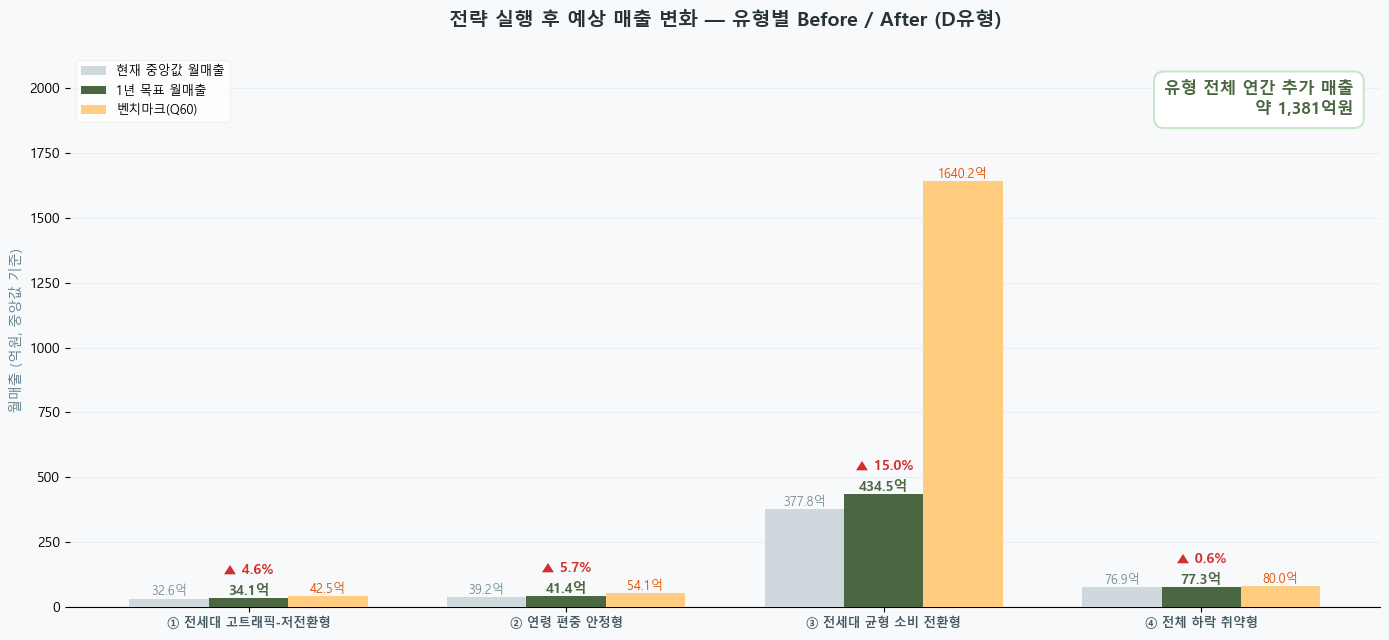

연간 추가 매출 유발 효과: 약 1,381억원


In [23]:
# ── Before / After 매출 비교 차트
유형_labels   = list(results.keys())
현재_vals     = [results[u]['현재_억']    for u in 유형_labels]
목표_vals     = [results[u]['목표_억']    for u in 유형_labels]
벤치마크_vals  = [results[u]['벤치마크_억'] for u in 유형_labels]

fig, ax = plt.subplots(figsize=(14, 6.5))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#F8F9FA')

x     = np.arange(len(유형_labels))
width = 0.25

bars_현재  = ax.bar(x - width, 현재_vals,    width, label='현재 중앙값 월매출', color='#CFD8DC', edgecolor='none', zorder=3)
bars_목표  = ax.bar(x,         목표_vals,    width, label='1년 목표 월매출',    color='#4a6741', edgecolor='none', zorder=3)
bars_bench = ax.bar(x + width, 벤치마크_vals, width, label='벤치마크(Q60)',     color='#FFCC80', edgecolor='none', zorder=3)

for bar in bars_현재:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.3, f'{h:.1f}억',
                ha='center', va='bottom', fontsize=9, color='#78909C')

for i, bar in enumerate(bars_목표):
    h = bar.get_height()
    개선율 = results[유형_labels[i]]['개선율_%']
    if h > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.3, f'{h:.1f}억',
                ha='center', va='bottom', fontsize=10, fontweight='bold', color='#4a6741')
        if 벤치마크_vals:
            ax.text(bar.get_x() + bar.get_width() / 2, h + max(벤치마크_vals) * 0.05,
                    f'▲ {개선율:.1f}%', ha='center', va='bottom', fontsize=10,
                    fontweight='bold', color='#D32F2F')

for bar in bars_bench:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.3, f'{h:.1f}억',
                ha='center', va='bottom', fontsize=9, color='#E65100')

# 유형명 축 레이블 줄여서 표시
short_labels = [u.split('(')[0].strip() if '(' in u else u for u in 유형_labels]
ax.set_xticks(x)
ax.set_xticklabels(short_labels, fontsize=9, fontweight='bold', color='#455A64')
ax.set_ylabel('월매출 (억원, 중앙값 기준)', fontsize=10, color='#607D8B')
ax.set_title('전략 실행 후 예상 매출 변화 — 유형별 Before / After (D유형)',
             fontsize=14, fontweight='bold', pad=20, color='#263238')
ax.grid(axis='y', linestyle='-', color='#ECEFF1', zorder=0)
sns.despine(left=True, bottom=False)
ax.legend(fontsize=9, loc='upper left', frameon=True, edgecolor='#EEEEEE', facecolor='white')
if 벤치마크_vals:
    ax.set_ylim(0, max(벤치마크_vals) * 1.3)

total_연간 = sum(results[u]['연간효과_억'] for u in 유형_labels)
ax.text(0.98, 0.95,
        f'유형 전체 연간 추가 매출\n약 {total_연간:,.0f}억원',
        transform=ax.transAxes, ha='right', va='top',
        fontsize=12, fontweight='bold', color='#4a6741',
        bbox=dict(boxstyle='round,pad=0.6', facecolor='white', edgecolor='#c8e6c9', linewidth=1.5))

plt.tight_layout()
plt.savefig('../data/output/D유형_전략_BeforeAfter.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'연간 추가 매출 유발 효과: 약 {total_연간:,.0f}억원')

---
## 4. 지도 시각화 — 유형별 상권 분포

In [24]:
# ── 유형별 색상 Folium 지도
color_map_folium = {
    '① 전세대 고트래픽-저전환형 (환승형)': '#2166ac',
    '② 연령 편중 안정형':                  '#d6604d',
    '③ 전세대 균형 소비 전환형':            '#1a9850',
    '④ 전체 하락 취약형':                  '#f4a582',
}

center_lat = g['lat'].mean()
center_lon = g['lon'].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=14,
    tiles='CartoDB positron'
)
MiniMap(toggle_display=True).add_to(m)

for 유형 in 유형_순서:
    subset = g[g['유형명'] == 유형].dropna(subset=['lat', 'lon'])
    color = color_map_folium.get(유형, '#888888')
    fg = folium.FeatureGroup(name=f'{유형} ({len(subset)}개)', show=True)

    for _, row in subset.iterrows():
        radius = max(4, min(18, row['총매출_억'] ** 0.4))
        popup_html = (
            f"<b>{row['상권_코드_명']}</b><br>"
            f"유형: {유형}<br>"
            f"월매출: {row['총매출_억']:.1f}억원<br>"
            f"객단가: {row['객단가']:,.0f}원<br>"
            f"연령 다양성: {row['연령다양성']:.2f}<br>"
            f"트래픽 전환율: {row['트래픽전환율']:,.0f}원/인"
        )
        folium.CircleMarker(
            location=[row['lat'], row['lon']],
            radius=radius,
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=0.65,
            weight=1.2,
            popup=folium.Popup(popup_html, max_width=230),
            tooltip=row['상권_코드_명'],
        ).add_to(fg)
    fg.add_to(m)

legend_html = """
<div style="position:fixed; bottom:30px; left:30px; z-index:9999;
     background:#fff; padding:12px 16px; border-radius:8px;
     border:1px solid #ccc; font-size:13px; line-height:1.8;">
  <b>D유형 상권 유형 (용산구)</b><br>
  <span style="color:#2166ac;">&#9679;</span> ① 전세대 고트래픽-저전환형 (환승형)<br>
  <span style="color:#d6604d;">&#9679;</span> ② 연령 편중 안정형<br>
  <span style="color:#1a9850;">&#9679;</span> ③ 전세대 균형 소비 전환형<br>
  <span style="color:#f4a582;">&#9679;</span> ④ 전체 하락 취약형<br>
  <small style="color:#888;">원 크기 ∝ 월매출 규모</small>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))
folium.LayerControl(collapsed=False).add_to(m)

out_path = '../data/output/D유형_클러스터_지도.html'
m.save(out_path)
print(f'저장 완료: {out_path}')
m

저장 완료: ../data/output/D유형_클러스터_지도.html


---
## 5. 연령대별 분기 매출 추이 — 아무도 멈추지 않는다

연령 다양성이 높다는 건 특정 세대가 소비를 주도하지 않는다는 뜻이기도 하다.  
2020~2025년 전체 분기 데이터를 통해 **각 연령대가 실제로 꾸준히 소비를 이어가고 있는지** 확인한다.

분석 연도: 2020 ~ 2025
포함 연령대: ['10대', '20대', '30대', '40대', '50대', '60대 이상']


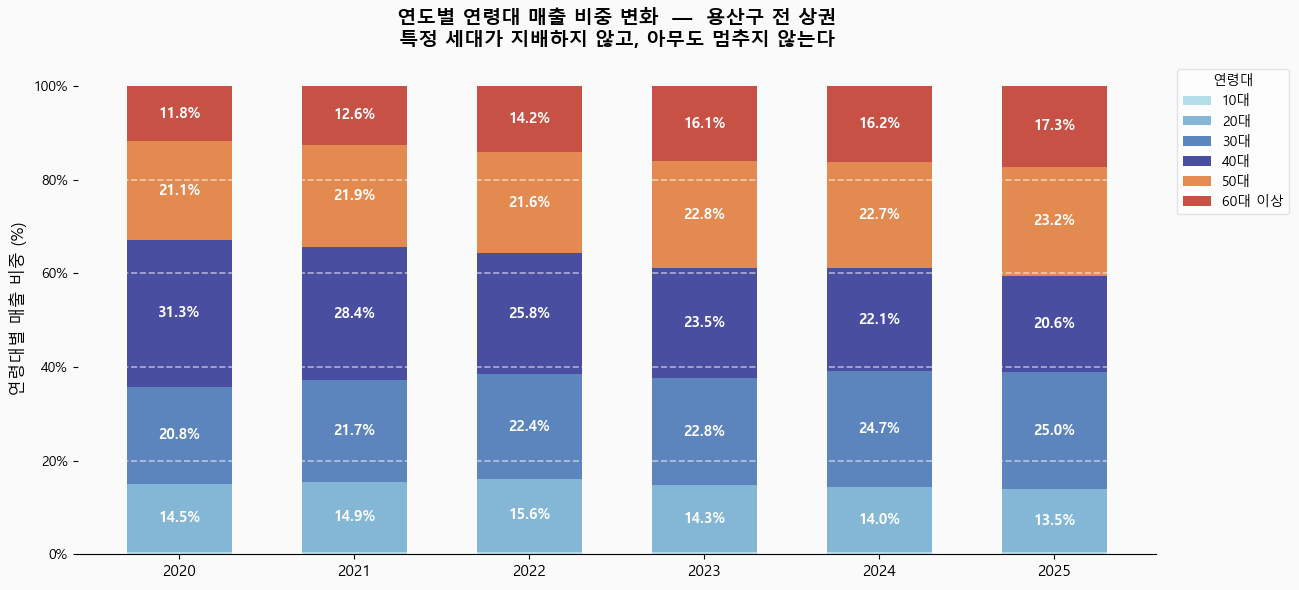


[연도별 연령대 매출 비중]
  2020년: 10대 0.4% / 20대 14.5% / 30대 20.8% / 40대 31.3% / 50대 21.1% / 60대 이상 11.8%
  2021년: 10대 0.5% / 20대 14.9% / 30대 21.7% / 40대 28.4% / 50대 21.9% / 60대 이상 12.6%
  2022년: 10대 0.5% / 20대 15.6% / 30대 22.4% / 40대 25.8% / 50대 21.6% / 60대 이상 14.2%
  2023년: 10대 0.4% / 20대 14.3% / 30대 22.8% / 40대 23.5% / 50대 22.8% / 60대 이상 16.1%
  2024년: 10대 0.4% / 20대 14.0% / 30대 24.7% / 40대 22.1% / 50대 22.7% / 60대 이상 16.2%
  2025년: 10대 0.4% / 20대 13.5% / 30대 25.0% / 40대 20.6% / 50대 23.2% / 60대 이상 17.3%


In [25]:

# ── 2020~2025 전체 연도 추정매출 로드 → 용산구 필터
_sales_dir = BASE / '서울시_상권분석서비스(추정매출+영역)'
all_year_files = sorted([f for f in _sales_dir.iterdir() if f.suffix == '.csv' and '추정매출' in f.name])

dfs_age = []
for f in all_year_files:
    try:
        tmp = pd.read_csv(f, encoding='euc-kr')
        tmp_d = tmp[tmp['상권_코드'].isin(target_codes)].copy()
        if len(tmp_d) > 0:
            dfs_age.append(tmp_d)
    except Exception as e:
        print(f'  ⚠️ {f.name}: {e}')

df_all_age = pd.concat(dfs_age, ignore_index=True)

AGE_COL_MAP = {
    '10대':     '연령대_10_매출_금액',
    '20대':     '연령대_20_매출_금액',
    '30대':     '연령대_30_매출_금액',
    '40대':     '연령대_40_매출_금액',
    '50대':     '연령대_50_매출_금액',
    '60대 이상': '연령대_60_이상_매출_금액',
}
AGE_COL_MAP = {k: v for k, v in AGE_COL_MAP.items() if v in df_all_age.columns}

# ── 연도별 합산
df_all_age['연도'] = df_all_age['기준_년분기_코드'].astype(str).str[:4].astype(int)
trend_yr = df_all_age.groupby('연도')[list(AGE_COL_MAP.values())].sum() / 1e8
trend_yr['총합'] = trend_yr.sum(axis=1)
trend_yr = trend_yr.reset_index()
years = trend_yr['연도'].astype(str).tolist()

print(f'분석 연도: {years[0]} ~ {years[-1]}')
print(f'포함 연령대: {list(AGE_COL_MAP.keys())}')

# ── 색상
AGE_COLORS = {
    '10대':     '#abd9e9',
    '20대':     '#74add1',
    '30대':     '#4575b4',
    '40대':     '#313695',
    '50대':     '#e07b39',
    '60대 이상': '#c0392b',
}

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('#fafafa')
ax.set_facecolor('#fafafa')

bottom = np.zeros(len(trend_yr))
for label, col in AGE_COL_MAP.items():
    pct = (trend_yr[col] / trend_yr['총합'] * 100).values
    ax.bar(years, pct, bottom=bottom,
           label=label, color=AGE_COLORS[label], alpha=0.88, width=0.6)
    for xi, (b, p) in enumerate(zip(bottom, pct)):
        if p >= 4.5:
            ax.text(xi, b + p / 2, f'{p:.1f}%',
                    ha='center', va='center', fontsize=10.5, color='white', fontweight='bold')
    bottom += pct

ax.axhline(20, color='white', linestyle='--', linewidth=1.2, alpha=0.55)
ax.axhline(40, color='white', linestyle='--', linewidth=1.2, alpha=0.55)
ax.axhline(60, color='white', linestyle='--', linewidth=1.2, alpha=0.55)
ax.axhline(80, color='white', linestyle='--', linewidth=1.2, alpha=0.55)

ax.set_ylim(0, 105)
ax.set_ylabel('연령대별 매출 비중 (%)', fontsize=12)
ax.set_title('연도별 연령대 매출 비중 변화  —  용산구 전 상권\n특정 세대가 지배하지 않고, 아무도 멈추지 않는다',
             fontsize=14, fontweight='bold', pad=12)
ax.legend(title='연령대', fontsize=10, title_fontsize=10,
          loc='upper right', frameon=True, facecolor='white', edgecolor='#ddd',
          bbox_to_anchor=(1.13, 1.0))
ax.tick_params(axis='x', labelsize=11)
ax.set_yticks([0, 20, 40, 60, 80, 100])
ax.set_yticklabels(['0%', '20%', '40%', '60%', '80%', '100%'], fontsize=10)
sns.despine(ax=ax, left=True)

plt.tight_layout()
plt.savefig('../data/output/D유형_연도별_연령대비중.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n[연도별 연령대 매출 비중]")
for _, row in trend_yr.iterrows():
    parts = [f"{label} {row[col]/row['총합']*100:.1f}%" for label, col in AGE_COL_MAP.items()]
    print(f"  {int(row['연도'])}년: {' / '.join(parts)}")
